In [9]:
# ==============================================================================
# PHẦN 2: HUẤN LUYỆN VÀ ĐÁNH GIÁ MÔ HÌNH HỌC MÁY (MACHINE LEARNING)
# Thực hiện: Thành viên C & D
# ==============================================================================

# Cell 1: Import thư viện
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
import xgboost as xgb

%matplotlib inline
sns.set_theme(style="whitegrid")



In [10]:
# Cell 2: Đọc tập dữ liệu đã qua xử lý (customer_features.csv)
current_dir = os.getcwd()
base_dir = os.path.dirname(current_dir) if 'notebooks' in current_dir else current_dir
data_path = os.path.join(base_dir, 'data', 'processed', 'customer_features.csv')

df = pd.read_csv(data_path)
print(f"Kích thước dữ liệu: {df.shape}")



Kích thước dữ liệu: (5000, 15)


In [11]:
# Cell 3: Tiền xử lý (Mã hóa và Tách biến)
# Bỏ cột Customer_ID vì nó là ID định danh, không mang giá trị toán học
X = df.drop(columns=['Customer_ID', 'Is_VIP'])
y = df['Is_VIP']

# One-Hot Encoding cho các biến chữ (Thương hiệu & Khu vực)
# drop_first=True giúp tránh bẫy biến giả (Dummy Variable Trap)
X = pd.get_dummies(X, columns=['Favorite_Brand', 'Location_Type'], drop_first=True)

# LƯU LẠI DANH SÁCH CỘT NÀY CHO APP STREAMLIT
feature_columns = X.columns.tolist()
print("Các cột đầu vào của mô hình:\n", feature_columns)



Các cột đầu vào của mô hình:
 ['Customer_Age', 'Membership_Months', 'Frequency', 'Recency', 'Monetary', 'Installment_Rate', 'Flagship_Ratio', 'Accessories_Ratio', 'Credit_Card_Usage', 'Warranty_Claims', 'App_Logins_L30D', 'Favorite_Brand_Oppo', 'Favorite_Brand_Samsung', 'Favorite_Brand_Xiaomi', 'Location_Type_Tier 2']


In [12]:
# Cell 4: Chia tập dữ liệu và Chuẩn hóa (Scaling)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
# Chỉ fit scaler trên tập Train để tránh Data Leakage
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Số mẫu Train: {X_train.shape[0]} | Số mẫu Test: {X_test.shape[0]}")



Số mẫu Train: 4000 | Số mẫu Test: 1000


In [13]:
# Cell 5: Xây dựng hàm đánh giá tổng quát
results = {}

def evaluate_model(model_name, y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)
    results[model_name] = {'Accuracy': acc, 'ROC_AUC': roc_auc}
    
    print(f"=== Đánh giá mô hình: {model_name} ===")
    print(f"Accuracy: {acc:.4f} | ROC-AUC: {roc_auc:.4f}\n")
    print("Classification Report:")
    print(classification_report(y_true, y_pred))
    
    # Vẽ Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('Thực tế')
    plt.xlabel('Dự đoán')
    plt.show()



=== Đánh giá mô hình: Logistic Regression (Baseline) ===
Accuracy: 0.8940 | ROC-AUC: 0.9559

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.93      0.93       702
           1       0.84      0.80      0.82       298

    accuracy                           0.89      1000
   macro avg       0.88      0.87      0.87      1000
weighted avg       0.89      0.89      0.89      1000



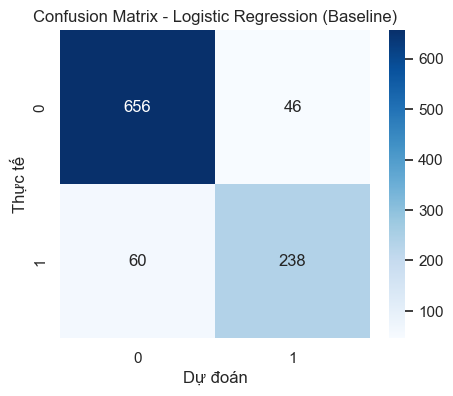

In [14]:
# Cell 6: Huấn luyện Baseline - Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]
evaluate_model("Logistic Regression (Baseline)", y_test, y_pred_lr, y_prob_lr)



=== Đánh giá mô hình: Random Forest ===
Accuracy: 0.9950 | ROC-AUC: 0.9999

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       702
           1       1.00      0.98      0.99       298

    accuracy                           0.99      1000
   macro avg       1.00      0.99      0.99      1000
weighted avg       1.00      0.99      0.99      1000



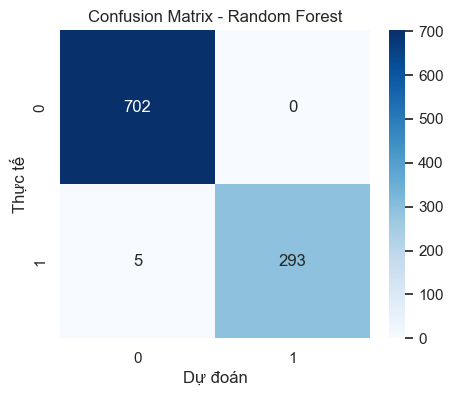

In [15]:
# Cell 7: Huấn luyện Standard ML - Random Forest
# RF không bắt buộc dùng Scale, nhưng dùng Scale giúp đồng bộ pipeline
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]
evaluate_model("Random Forest", y_test, y_pred_rf, y_prob_rf)



d:\CDIO\.venv\lib\site-packages\xgboost\data.py:440: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(data):


=== Đánh giá mô hình: XGBoost ===
Accuracy: 0.9970 | ROC-AUC: 0.9999

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       702
           1       0.99      1.00      0.99       298

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



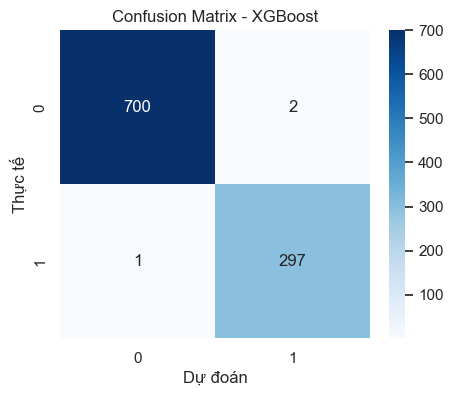

In [16]:
# Cell 8: Huấn luyện Advanced ML - XGBoost
xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train_scaled, y_train)

y_pred_xgb = xgb_model.predict(X_test_scaled)
y_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]
evaluate_model("XGBoost", y_test, y_pred_xgb, y_prob_xgb)



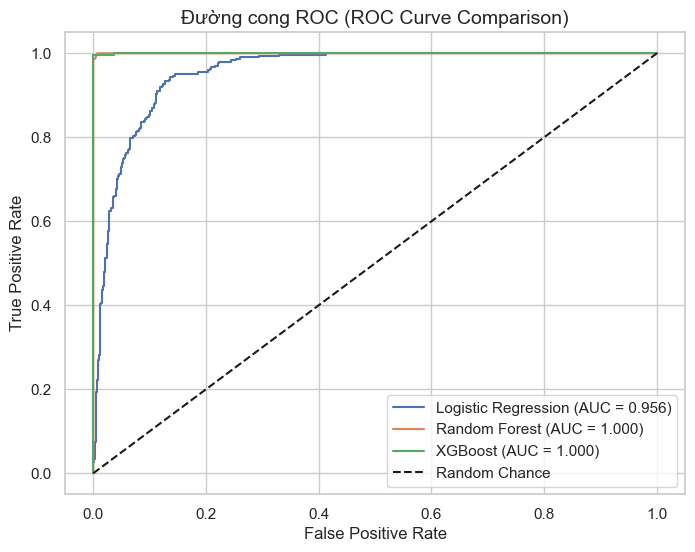

In [17]:
# Cell 9: So sánh ROC Curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {results['Logistic Regression (Baseline)']['ROC_AUC']:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {results['Random Forest']['ROC_AUC']:.3f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {results['XGBoost']['ROC_AUC']:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Đường cong ROC (ROC Curve Comparison)', fontsize=14)
plt.legend()
plt.show()



d:\CDIO\.venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
d:\CDIO\.venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
d:\CDIO\.venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


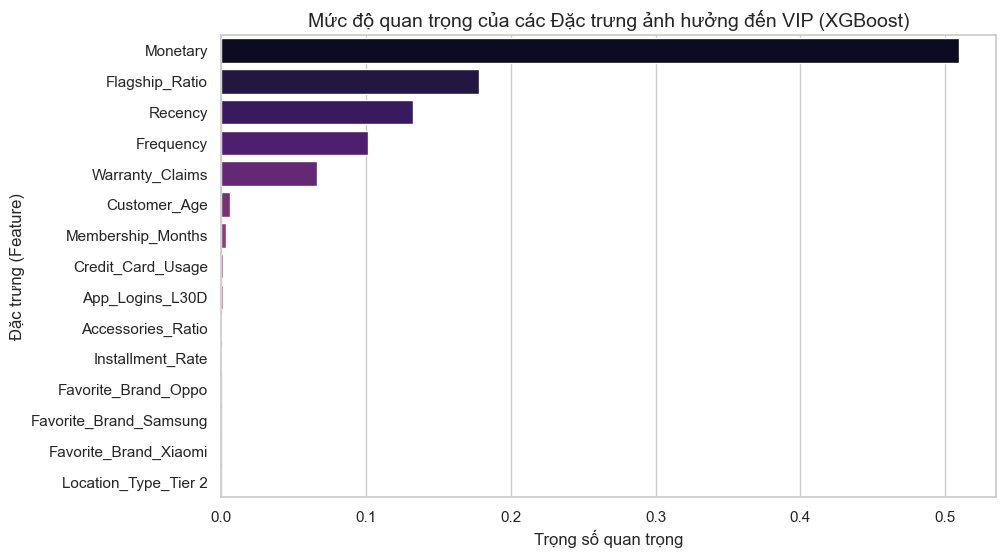

🎉 Đã huấn luyện xong! Các file model.pkl, scaler.pkl đã được lưu vào thư mục models/.


In [19]:
# Cell 10: Trích xuất Tầm quan trọng của Đặc trưng (Feature Importance) từ XGBoost
feature_importances = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances, palette='magma')
plt.title('Mức độ quan trọng của các Đặc trưng ảnh hưởng đến VIP (XGBoost)', fontsize=14)
plt.xlabel('Trọng số quan trọng')
plt.ylabel('Đặc trưng (Feature)')
plt.show()

# Cell 11: Đóng gói và Lưu Mô hình
models_dir = os.path.join(base_dir, 'models')
os.makedirs(models_dir, exist_ok=True)

# Lưu Model, Scaler và danh sách cột
joblib.dump(xgb_model, os.path.join(models_dir, 'best_xgb_model.pkl'))
joblib.dump(scaler, os.path.join(models_dir, 'scaler.pkl'))
joblib.dump(feature_columns, os.path.join(models_dir, 'feature_columns.pkl'))

print("🎉 Đã huấn luyện xong! Các file model.pkl, scaler.pkl đã được lưu vào thư mục models/.")